# Load and test saved model

In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product
from jax.nn import relu
import jax.numpy as jnp
from jax.typing import ArrayLike
import jax
from WMSE import WMSE, WMSE_metric


jax.config.update("jax_enable_x64", False)

#### graphical
import matplotlib.pyplot as plt
import corner
import matplotlib

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers
from matplotlib.gridspec import GridSpec
##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="0"

physical_devices = tf.config.list_physical_devices("GPU") 

tf.config.experimental.set_memory_growth(physical_devices[0], True)

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

modelpath = '/home/hatte/M4/models'

2025-04-14 08:26:18.089425: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744615578.100964 3362729 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744615578.104624 3362729 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Current GPU usage:
 - GPU0: 0B



I0000 00:00:1744615580.006260 3362729 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13327 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


In [2]:
df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df') ## edit for your grid!!

df_full['logLPhot'] = np.log10(df_full['LPhot'])

df_full['lognumax'] = np.log10(df_full['numax']*3090)

df_full['logdnuSer'] = np.log10(df_full['dnuSer']*135)

df_full['logAge'] = np.log10(df_full['age'])

#### define inputs
inputs = ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe']

#### define outputs
classical_outputs = ['FeH', 'logLPhot', 'Teff']
astero_outputs = ['lognumax', 'logdnuSer']  # 10 modes for now

outputs = classical_outputs+astero_outputs

df = df_full[inputs+outputs]

df_norm = (df - df.min())/(df.max() - df.min())

## check df_norm.describe looks reasonable (min=0, max=1):
df_norm.describe()



,massini,zini,yini,alphaMLT,logAge,eta,alphaFe,FeH,logLPhot,Teff,lognumax,logdnuSer
count,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06,7.483746e+06
mean,5.320517e-01,1.169785e-01,4.801320e-01,5.207879e-01,5.600889e-01,4.995957e-01,5.104678e-01,5.510095e-01,6.590481e-01,1.893095e-01,3.204782e-01,3.007441e-01
std,2.741396e-01,1.503168e-01,2.866208e-01,2.874298e-01,2.294823e-01,2.886541e-01,3.224309e-01,2.766927e-01,1.768257e-01,6.669141e-02,2.203469e-01,2.388832e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.050000e-01,1.490123e-02,2.313656e-01,2.751358e-01,3.773491e-01,2.494505e-01,2.500000e-01,3.284310e-01,5.532432e-01,1.458403e-01,1.430966e-01,1.080578e-01
50%,5.362500e-01,5.506925e-02,4.703010e-01,5.304316e-01,5.534359e-01,4.997558e-01,5.000000e-01,5.743831e-01,6.935266e-01,1.897028e-01,2.651610e-01,2.382943e-01
75%,7.675000e-01,1.620700e-01,7.242537e-01,7.715646e-01,7.451413e-01,7.497558e-01,7.500000e-01,7.868256e-01,7.945543e-01,2.266111e-01,4.502288e-01,4.408151e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [3]:
unnormed_weights_dict = {'FeH':0.01, 'logLPhot':0.001, 'Teff':10, 'lognumax':0.0001, 'logdnuSer':0.0001}

unnormed_weights = list(unnormed_weights_dict.values())

weights = [2*unnormed_weights_dict[i]/(df[i].max() - df[i].min()) for i in outputs]

In [4]:
weights

[np.float64(0.00902176473219089),
 np.float64(0.0009398816379978598),
 np.float64(0.0032524327234457837),
 np.float64(0.00010740247435805763),
 np.float64(0.00015030428317496362)]

In [5]:
from pypalettes import load_cmap


Peach = load_cmap('Peach', cmap_type = 'continuous')

Concha = load_cmap('Concha', cmap_type = 'continuous')

Magenta = load_cmap('Magenta', cmap_type = 'continuous')

Burg = load_cmap('Burg', cmap_type = 'continuous')

DM = load_cmap('DarkMint', cmap_type = 'continuous')

In [6]:
#### train/test split with seed 
seed = 42

df_train = df_norm.sample(frac=0.95, random_state=seed)
df_test = df_norm.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.05, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Validation set: ", len(df_val_inputs))
print("Test set: ", len(df_test))

Training set:  6754081
Validation set:  355478
Test set:  374187


In [7]:
######## define architecture:
n_dense_layers = 6

dense_layer_units = 128

Nepochs = 5000

learning_rate = 0.0001

model_name = 'logAge-logLPhot-lognumax-logdnuSer-exponent-6e-6-Adam'

loss_func = 'WMSE'
###### Checkpointing

custom_objects =  {'WMSE':WMSE_metric}

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

model= tf.keras.models.load_model(checkpoint_dir, custom_objects = custom_objects)


In [8]:
model.summary()

Model: "logAge-logLPhot-lognumax-logdnuSer-exponent-6e-6-Adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,689 (987.07 KB)

 Trainable params: 84,229 (329.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 168,460 (658.05 KB)

In [9]:
def unnorm(df_norm, df_min, df_max):
    df_unnorm = (df_norm*(df_max-df_min)) + df_min
    return df_unnorm

preds_norm = model(np.array(df_test[inputs]))

df_preds_norm = pd.DataFrame(preds_norm, columns=outputs)
df_preds_unnorm = unnorm(df_preds_norm, df[outputs].min(), df[outputs].max())

df_test_unnorm = unnorm(df_test, df.min(), df.max())

In [10]:
def plot_residuals(test, preds, outputs, units, factor, filename, typical, colors, save = False, labels = ['[Fe/H]', r'L$_{\mathrm{phot, }}$', r'T$_{\mathrm{eff, }}$', r'$\nu_{\mathrm{max, }}$', r'$\Delta\nu$']):
    
    fig = plt.figure(figsize = (20, 3))
    
    gs = GridSpec(1, len(outputs), wspace = 0.2)
    
    axs = [fig.add_subplot(gs[i]) for i in range(len(outputs))]

    for i in range(len(outputs)):
        if 'log' in outputs[i]:

            residual = (10**df_test_unnorm[outputs[i]].values*factor[i] - 10**df_preds_unnorm[outputs[i]].values*factor[i])

            name = outputs[i].split('log')[1]
        ##Summary stats##
            mean = np.mean(residual)
        
            std = np.std(residual)

            quantiles = [np.quantile(residual, j) for j in [0.16, 0.5, 0.84]]
        
            ranges = [quantiles[1] + 6*quantiles[0], quantiles[1] + 6*quantiles[2]]

            
            axs[i].hist(residual,\
                    bins = 100, density = True, range = ranges, histtype = 'step', fill = True, facecolor = colors[i],\
                   edgecolor = 'black', linewidth = 1)
        
            axs[i].set_xlabel(f'{labels[i]}'r'$_{\mathrm{test}}$'r'$-$'f'{labels[i]}'r'$_{\mathrm{pred}}$ 'f'[{units[i]}]')

        else:

            residual = df_test_unnorm[outputs[i]].values*factor[i] - df_preds_unnorm[outputs[i]].values*factor[i]
            
            mean = np.mean(residual)
        
            std = np.std(residual)
        
            quantiles = [np.quantile(residual, j) for j in [0.16, 0.5, 0.84]]

            ranges = [quantiles[1] + 6*quantiles[0], quantiles[1] + 6*quantiles[2]]

            axs[i].hist(residual,\
                    bins = 100, density = True, range = ranges, histtype = 'step', fill = True, facecolor = colors[i],\
                   edgecolor = 'black', linewidth = 1)

            axs[i].set_xlabel(f'{labels[i]}'r'$_{\mathrm{test}}$'r'$-$'f'{labels[i]}'r'$_{\mathrm{pred}}$ 'f'[{units[i]}]')
        
        axs[i].axvline(quantiles[1] + quantiles[0], color = 'black', linestyle = '--', label = f'std = {round(std, 2)}')
        
        axs[i].axvline(quantiles[1] + quantiles[2], color = 'black', linestyle = '--', )

#        axs[i].axvspan(quantiles[1] + quantiles[0], quantiles[1] + quantiles[2], color = 'deeppink', alpha = 0.2)

        axs[i].axvspan(-1*typical[i], typical[i], color = 'grey', alpha = 0.3, )
        
 #       axs[i].axvline(mean, color = 'black',  label = f'mean = {round(mean, 2)}', linewidth = 2)
        
        axs[i].set_title(r'$q_{50}$ ='f'{round(mean, 2)}, 'r'$q_{16}$ ='f'{round(quantiles[0], 2)}, 'r'$q_{84}$ ='f'{round(quantiles[2], 2)}')

        axs[i].set_yticks([])
    
    if save == True:
        fig.savefig(f'../figs/{filename}-residuals.png', bbox_inches = 'tight', dpi = 150)


    return fig

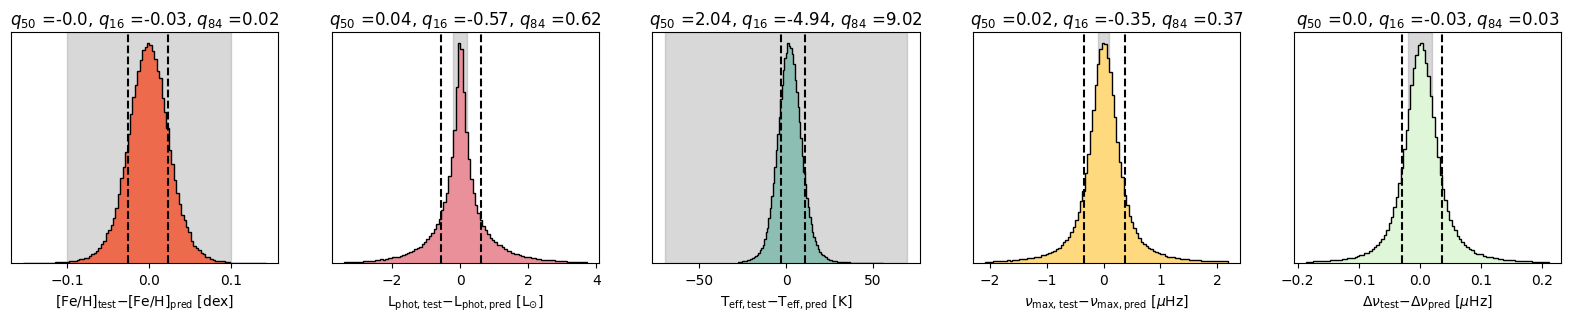

In [11]:
units = ['dex', r'L$_{\odot}$', 'K', r'$\mu$Hz', r'$\mu$Hz']
solarnumax = 3090
solardnu = 135
factor = [1, 1, 1, 1, 1]
typ = [0.1, 0.2, 70, 0.1, 0.02]
colors = [Concha.colors[3], Magenta.colors[3], Peach.colors[3], Burg.colors[3], DM.colors[3]]
colors = ['#ee6a4d', '#e9909b', '#8cbeb3', '#FFD97D', '#E0F6D8']

fig = plot_residuals(df_test_unnorm, df_preds_unnorm, outputs, units, factor, filename = f'{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}', save = True, typical = typ, colors = colors)

NameError: name 'norm' is not defined

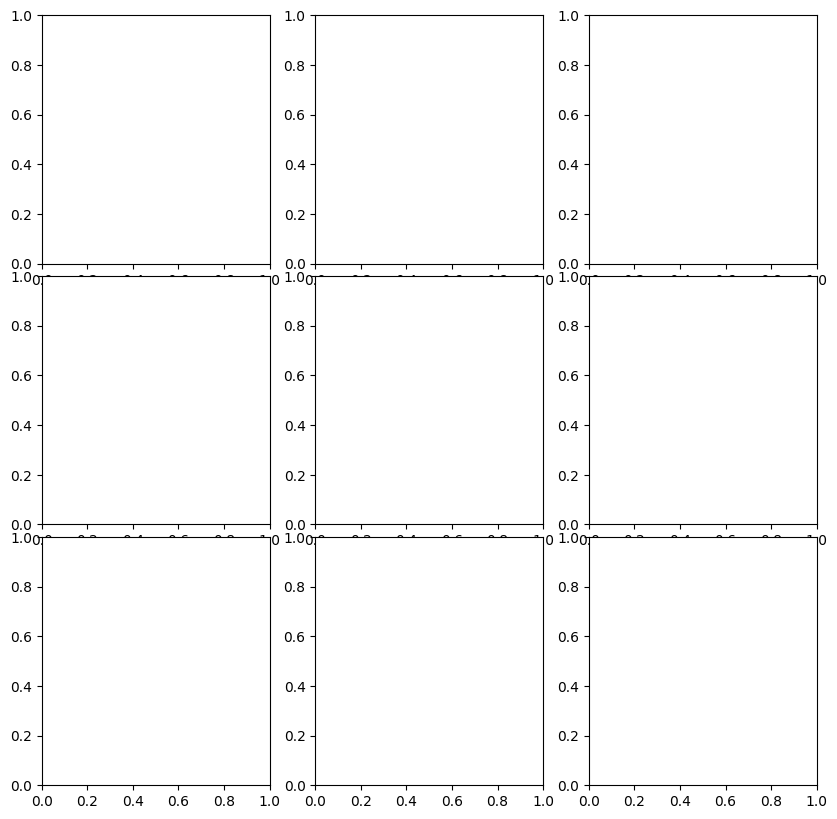

In [14]:
colors = ['mediumturquoise', 'salmon', 'cornflowerblue']

fig = plt.figure(figsize = (10,10))

gs = GridSpec(3, 3, wspace = 0.2, hspace = 0.05)
axs_row1 = [fig.add_subplot(gs[0, i]) for i in range(3)]
axs_row2 = [fig.add_subplot(gs[1, i]) for i in range(3)]
axs_row3 = [fig.add_subplot(gs[2, i]) for i in range(3)]

axs = np.vstack([axs_row1, axs_row2, axs_row3])

masses = [norm(i, 'massini', normconsts) for i in [0.7, 1.1, 1.5]]
metals = [norm(i, 'FeH', normconsts) for i in [-1, -0.5, 0]]
for k in range(len(masses)):
    df_ = df_norm[df_norm['massini'] == masses[k]]
    for j in range(len(metals)):
        diff_met = np.abs(df_['FeH'] - metals[j])
        star = df_norm.loc[[diff_met.sort_values().index[0]]]
        track_star = df_norm.merge(star[['massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']])
        testerdf = pd.DataFrame(columns = inputs)
        testerdf['age'] = np.linspace(np.min(track_star['age']), np.max(track_star['age']), 1000)

        for i in ['massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']:
            testerdf[i] = star[i].values[0]


        testerout = model(np.array(testerdf)).numpy()

        axs[k, j].semilogy(unnorm(track_star['Teff'], 'Teff', normconsts), 10**unnorm(track_star['logLPhot'], 'logLPhot', normconsts), color = colors[j], linestyle= '--', linewidth = 2.5)
        axs[k, j].semilogy(unnorm(testerout.T[2], 'Teff', normconsts), 10**unnorm(testerout.T[1], 'logLPhot', normconsts), color = colors[j], label = f'{[0.7, 1.1, 1.5][k]}'r'M$_{\odot}$', linewidth = 2.5)
        axs[k, j].set_ylim(10**0.4, 10**2.3)
        axs[k, j].set_xlim(4000, 8000)
        axs[k, j].invert_xaxis()
        axs[k, j].legend()
        if k < 2:
            axs[k, j].set_xticks([])

        else:
            axs[k, j].set_xlabel(r'T$_{\mathrm{eff}}$ [K]')

        if j > 0:
            axs[k, j].set_yticks([])

        else:
            axs[k, j].set_ylabel(r'Luminosity [L$_{\odot}$]')

axs[0, 0].set_title(r'[Fe/H] = -1dex')
axs[0, 1].set_title(r'[Fe/H] = -0.5dex') 
axs[0, 2].set_title(r'[Fe/H] = 0dex') 

#fig.savefig(f'../figs/trackwise-predictions-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}.png', bbox_inches = 'tight', dpi = 150)
